## 1. Data Cleaning

In [5]:
import pandas as pd

dataset = pd.read_excel('data/Online Retail.xlsx')
dataset.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
dataset = dataset.dropna(subset=['Description', 'CustomerID'])

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [11]:
dataset = dataset[~dataset['InvoiceNo'].astype(str).str.startswith('C')]

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [12]:
dataset.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Feature Engineering

In [20]:
dataset_final = dataset.copy()

dataset_final['TotalAmount'] = dataset_final['Quantity'] * dataset_final['UnitPrice']

reference_date = dataset_final['InvoiceDate'].max()

rfm = dataset_final.groupby("CustomerID").agg(
    LastPurchase = ('InvoiceDate', 'max'),
    Frequency = ('InvoiceNo', 'count'),
    Monetary = ('TotalAmount', 'sum')
).reset_index()

rfm['Recency'] = (
    reference_date - rfm['LastPurchase']
).dt.days

rfm = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']]

rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,182,4310.00
2,12348.0,74,31,1797.24
3,12349.0,18,73,1757.55
4,12350.0,309,17,334.40
...,...,...,...,...
4334,18280.0,277,10,180.60
4335,18281.0,180,7,80.82
4336,18282.0,7,12,178.05
4337,18283.0,3,756,2094.88


In [38]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4339 non-null   float64
 1   Recency     4339 non-null   int64  
 2   Frequency   4339 non-null   int64  
 3   Monetary    4339 non-null   float64
 4   Cluster     4339 non-null   int32  
dtypes: float64(2), int32(1), int64(2)
memory usage: 152.7 KB


## 3. K-Means Clustering

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled

,Recency,Frequency,Monetary
0,2.334858,-0.396512,8.359634
1,-0.905199,0.394688,0.251046
2,-0.175186,-0.265374,-0.028546
3,-0.735196,-0.081781,-0.032963
4,2.174855,-0.326572,-0.191315
...,...,...,...
4334,1.854850,-0.357171,-0.208429
4335,0.884833,-0.370285,-0.219531
4336,-0.845198,-0.348428,-0.208712
4337,-0.885199,2.903796,0.004572


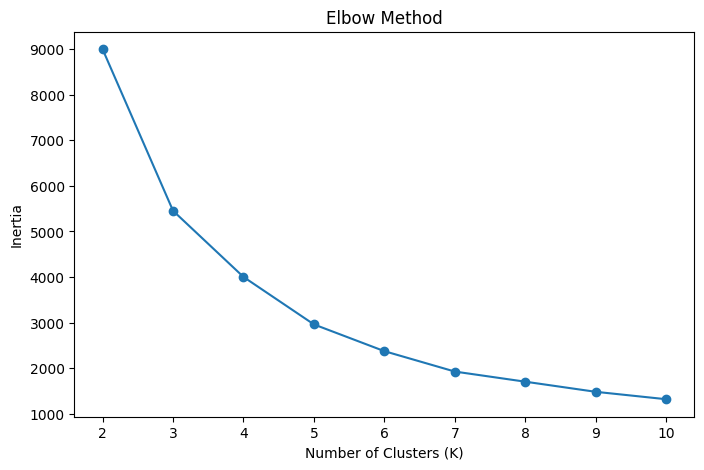

In [26]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,325,1,77183.60,2
1,12347.0,1,182,4310.00,0
2,12348.0,74,31,1797.24,0
3,12349.0,18,73,1757.55,0
4,12350.0,309,17,334.40,1
...,...,...,...,...,...
4334,18280.0,277,10,180.60,1
4335,18281.0,180,7,80.82,1
4336,18282.0,7,12,178.05,0
4337,18283.0,3,756,2094.88,2


In [32]:
rfm['Cluster'].value_counts()

Cluster
0    3036
1    1055
2     238
4       6
3       4
Name: count, dtype: int64

In [33]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Tambahkan jumlah customer per cluster
cluster_summary['Count'] = rfm['Cluster'].value_counts()

# Tambahkan kolom Persona
cluster_labels = {
    0: 'Standard / Occasional Customers',
    1: 'At Risk / Lapsed Customers',
    2: 'Loyal High-Value Customers',
    3: 'Outlier Wholesale/B2B Accounts',
    4: 'Outlier Wholesale/B2B Accounts'
}
cluster_summary['Persona'] = cluster_summary.index.map(cluster_labels)

cluster_summary

,Recency,Frequency,Monetary,Count,Persona
Cluster,,,,,
0,43.255270,73.839921,1346.975156,3036,Standard / Occasional Customers
1,248.476777,27.793365,490.446645,1055,At Risk / Lapsed Customers
2,15.075630,488.344538,12082.723529,238,Loyal High-Value Customers
3,1.000000,5807.750000,70925.287500,4,Outlier Wholesale/B2B Accounts
4,6.666667,827.833333,190863.461667,6,Outlier Wholesale/B2B Accounts


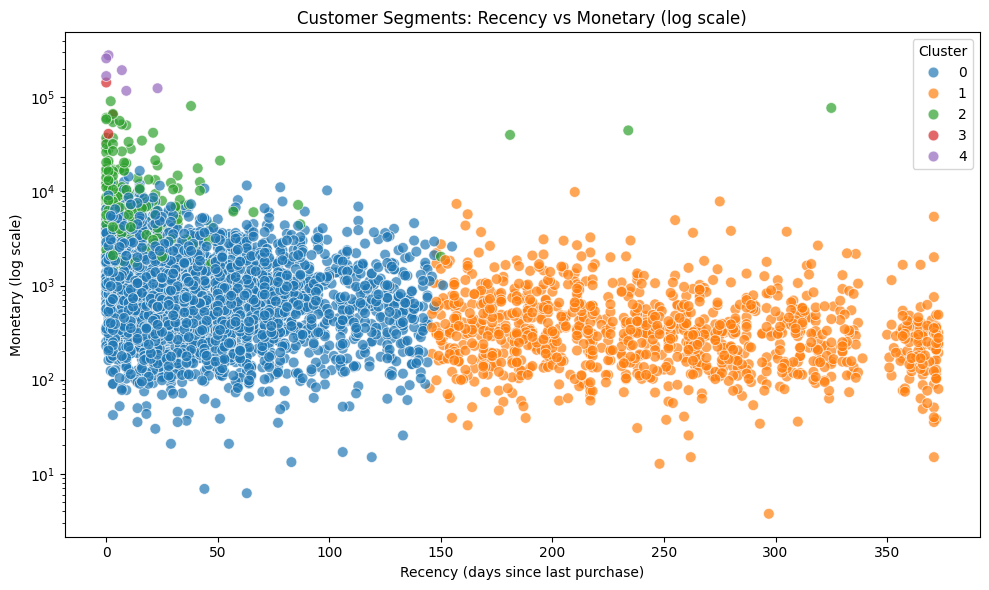

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='tab10',
    s=60,
    alpha=0.7
)

plt.yscale('log')  # penting karena Monetary Cluster 3/4 jauh lebih besar dari yang lain
plt.title('Customer Segments: Recency vs Monetary (log scale)')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (log scale)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 4. Summary

1. Cluster 0, Standard / Occasional Customers (3,036 customers, 69.7% of the base)
This is the largest segment by far, with moderate recency (43 days), low-to-moderate frequency (74 transactions), and modest monetary value (1,347). These customers are engaged but not deeply loyal, representing the bulk of the addressable market. The recommendation is to run broad, low-cost reactivation campaigns such as newsletters, seasonal promotions, and product recommendations designed to nudge them toward more frequent purchasing, since even a small uplift across this segment has outsized revenue impact given its size.

2. Cluster 1, At Risk / Lapsed Customers (1,055 customers, 24.3% of the base)
This segment has by far the highest recency (248 days since last purchase) alongside the lowest frequency and monetary value of any non-outlier cluster. These customers were once active but have gone quiet for an extended period and are at high risk of permanent churn. The recommendation is a targeted win-back campaign with a meaningful incentive (a significant discount or a personalized offer referencing their past purchase history), since generic promotions are unlikely to be enough to re-engage a segment this disengaged.

3. Cluster 2, Loyal High-Value Customers (238 customers, 5.5% of the base)
This segment combines strong recency (15 days), high frequency (488 transactions), and high monetary value (12,083), making it the healthiest mainstream segment in the customer base. The recommendation is to protect and grow this group through a formal loyalty or VIP tier, proactive cross-sell and upsell offers, and early access to new products, since retaining and expanding this segment is likely to be more cost-effective than acquiring new customers of similar value.


5. Clusters 3 and 4, Outlier Wholesale/B2B Accounts (combined 10 customers, 0.23% of the base)
These two clusters show extreme frequency (5,808 and 828 transactions) and extreme monetary value (70,925 and 190,863), far beyond any pattern seen in the rest of the customer base. This strongly suggests wholesale, reseller, or B2B accounts rather than typical retail shoppers, and K-Means has correctly isolated them as statistically distinct. The recommendation is to exclude this group entirely from mass-market segmentation campaigns and instead manage them through dedicated account management, with negotiated pricing and personalized service, since a standard retail promotion would be both irrelevant and potentially costly at this order volume.

5. The clustering results reveal a customer base that is overwhelmingly composed of standard, moderately engaged shoppers (Cluster 0), with a substantial at-risk segment (Cluster 1) that requires active win-back effort to prevent further churn. A small but highly valuable loyal segment (Cluster 2) represents the healthiest part of the retail customer base and should be prioritized for retention. Finally, the clustering surfaced a tiny group of extreme outliers (Clusters 3 and 4) whose transaction volumes are inconsistent with typical retail behavior, indicating wholesale or B2B accounts that require an entirely different, non-marketing-driven engagement strategy. Overall, the segmentation confirms that customer value in this dataset is highly concentrated: a small fraction of customers (Cluster 2 plus the outlier accounts) accounts for a disproportionate share of total transaction volume and revenue, reinforcing the importance of retention-focused strategy over broad-based acquisition.